# Broadband qubit spectroscopy

In [10]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.experiments.cal06_qubit_spectroscopy_full_bandwidth import BroadbandQubitSpectroscopy

## Run parameters

In [11]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If use None, it will not change the value already in the hardware
OUTPUT_DIR = Path("data")

QUBITS = ["q1"]
FREQUENCY_CENTER = 2941490601
FREQUENCY_WIDTH = 30e6
FREQUENCY_POINTS = 101
MAXIMUM_BRANCH_WIDTH = 800e6
REPETITIONS = 100
DRIVE_AMPLITUDE = 0.9
DRIVE_DURATION = 100e-5

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
RESTORE_DRIVE_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config   # Use None if param persisting is not required

## Hardware and experiment

In [12]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = BroadbandQubitSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

In [13]:
print(hardware_agent.quantum_device)

name='dut_config_AS_QRC' elements={'q1': BasicTransmonElement(name='q1', element_type='BasicTransmonElement', reset=IdlingReset(name='reset', duration=0.00273), rxy=RxyDRAG(name='rxy', amp180=0.5065297196048616, beta=0.0, duration=3e-07, reference_magnitude=ReferenceMagnitude(name='reference_magnitude', dBm=nan, V=nan, A=nan)), measure=DispersiveMeasurement(name='measure', pulse_type='SquarePulse', pulse_amp=0.075, pulse_duration=1.8e-05, acq_channel=0, acq_delay=3.59e-07, integration_time=1.8e-05, reset_clock_phase=True, acq_weights_a=array([], dtype=float64), acq_weights_b=array([], dtype=float64), acq_weights_sampling_rate=1.0, acq_weight_type='SSB', acq_rotation=307.8338024122479, acq_threshold=-0.00043972049135668944, num_points=1, reference_magnitude=ReferenceMagnitude(name='reference_magnitude', dBm=nan, V=nan, A=nan)), pulse_compensation=PulseCompensationModule(name='pulse_compensation', max_compensation_amp=0.0, time_grid=0.0, sampling_rate=0.0, min_duration=nan), ports=Ports(

## Branch plan

In [14]:
branches = experiment.plan_branches(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
)
for branch in branches:
    print(
        f"Branch {branch.index + 1}: "
        f"{branch.start / 1e9:.6f}-{branch.stop / 1e9:.6f} GHz, "
        f"LO {branch.lo_frequency / 1e9:.6f} GHz, "
        f"{branch.points} points"
    )

Branch 1: 2.926491-2.956491 GHz, LO 2.941491 GHz, 101 points


## Measurement

In [15]:

dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
    repetitions=REPETITIONS,
    drive_amplitude=DRIVE_AMPLITUDE,
    drive_duration=DRIVE_DURATION,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    restore_drive_lo_frequency=RESTORE_DRIVE_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 3kB
Dimensions:           (acq_index_S21_q1: 101)
Coordinates:
    frequency_q1      (acq_index_S21_q1) float64 808B 2.926e+09 ... 2.956e+09
  * acq_index_S21_q1  (acq_index_S21_q1) int64 808B 0 1 2 3 4 ... 97 98 99 100
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 2kB (-0.00027646722616972...
Attributes:
    tuid:     20260825-044327-141-ac7b9d

## Optional: Simulated data

In [16]:
# dataset = experiment.simulated_data(
#     frequency_center=FREQUENCY_CENTER,
#     frequency_width=FREQUENCY_WIDTH,
#     frequency_points=FREQUENCY_POINTS,
#     qubit_frequency=5.444e9,
#     linewidth=10e6,
#     phase_offset=0.0,
#     noise=0.002,
#     seed=42,
# )

## Analysis

In [17]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: f01 = {result.frequency / 1e9:.9f} GHz, "
            f"linewidth = {result.linewidth / 1e6:.3f} MHz"
        )
    else:
        print(f"{qubit}: qubit-spectroscopy fit failed")

q1: f01 = 2.941609580 GHz, linewidth = 19.029 MHz


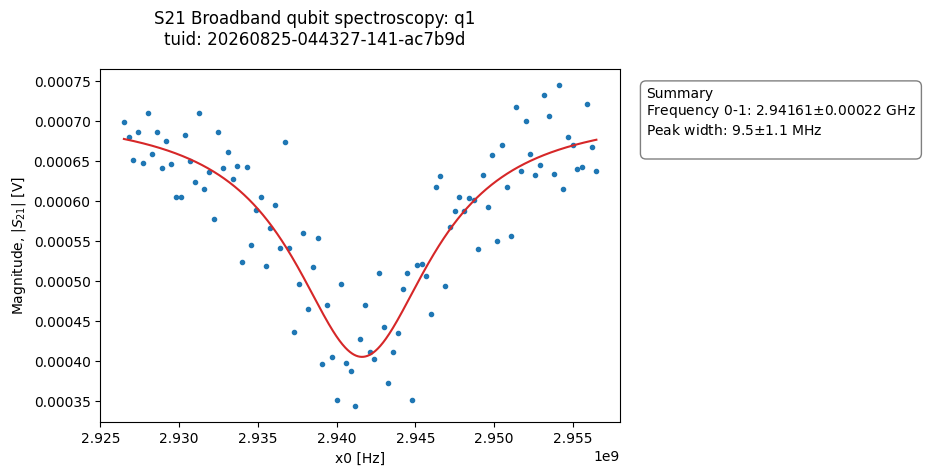

In [18]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [19]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()